In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
from pathlib import Path

traffic_file = "laei-2019-major-roads-vkm-flows-speeds.csv"

file_path = Path(traffic_file)

print("File exists:", file_path.exists())
print("File name:", file_path.name)
print("File size (MB):", round(file_path.stat().st_size / 1024 / 1024, 2))

File exists: True
File name: laei-2019-major-roads-vkm-flows-speeds.csv
File size (MB): 22.4


In [5]:
with open(traffic_file, "rb") as file:
    first_bytes = file.read(4)

print(first_bytes)

b'PK\x03\x04'


In [6]:
excel_file = pd.ExcelFile(traffic_file)

print(excel_file.sheet_names)

['laei-2019-major-roads']


In [8]:
traffic_df = pd.read_excel(
    traffic_file,
    sheet_name="laei-2019-major-roads"
)

In [9]:
print("Shape:")
print(traffic_df.shape)

print("\nFirst 5 rows:")
print(traffic_df.head())

print("\nColumns:")
print(traffic_df.columns.tolist())

print("\nDataset information:")
traffic_df.info()

Shape:
(79437, 48)

First 5 rows:
   Year                  TOID LAEI Zone  Borough Road Classification  \
0  2019  osgb4000000027947700   Non-GLA  Non-GLA              A Road   
1  2019  osgb4000000027908760   Non-GLA  Non-GLA              A Road   
2  2019  osgb4000000027987795   Non-GLA  Non-GLA              A Road   
3  2019  osgb4000000027869099   Non-GLA  Non-GLA              A Road   
4  2019  osgb4000000030443012   Non-GLA  Non-GLA              A Road   

   AADT Motorcycle   AADT Taxi   AADT Petrol Car   AADT Diesel Car   \
0               112          15              5470              3780   
1                68          10              3049              2107   
2               131          15              5752              3976   
3               178          14              7280              5031   
4               178          34              8433              5828   

   AADT Electric Car   ...  VKM Electric LGV   \
0                  32  ...                 50   
1       

In [10]:
traffic_df.columns = traffic_df.columns.str.strip()

print(traffic_df.columns.tolist())

['Year', 'TOID', 'LAEI Zone', 'Borough', 'Road Classification', 'AADT Motorcycle', 'AADT Taxi', 'AADT Petrol Car', 'AADT Diesel Car', 'AADT Electric Car', 'AADT Petrol PHV', 'AADT Diesel PHV', 'AADT Electric PHV', 'AADT Petrol LGV', 'AADT Diesel LGV', 'AADT Electric LGV', 'AADT 2019 - HGVs - Rigid - 2 Axles', 'AADT 2019 - HGVs - Rigid - 3 Axles', 'AADT 2019 - HGVs - Rigid - 4 or more Axles', 'AADT 2019 - HGVs - Articulated - 3 to 4 Axles', 'AADT 2019 - HGVs - Articulated - 5 Axles', 'AADT 2019 - HGVs - Articulated - 6 Axles', 'AADT 2019 - Buses', 'AADT 2019 - Coaches', 'AADT 2019 - Total', 'Speed (km/hr) - Except Buses', 'Speed (km/hr) - Buses Only', 'Link Length (m)', 'VKM Motorcycle', 'VKM Taxi', 'VKM Petrol Car', 'VKM Diesel Car', 'VKM Electric Car', 'VKM Petrol PHV', 'VKM Diesel PHV', 'VKM Electric PHV', 'VKM Petrol LGV', 'VKM Diesel LGV', 'VKM Electric LGV', 'VKM 2019 - HGVs - Rigid - 2 Axles', 'VKM 2019 - HGVs - Rigid - 3 Axles', 'VKM 2019 - HGVs - Rigid - 4 or more Axles', 'VKM 

In [11]:
print("Shape:", traffic_df.shape)
print("Years:", traffic_df["Year"].unique())
print("Missing TOIDs:", traffic_df["TOID"].isna().sum())
print("Duplicate TOIDs:", traffic_df["TOID"].duplicated().sum())
print("Number of borough categories:", traffic_df["Borough"].nunique())

Shape: (79437, 48)
Years: [2019]
Missing TOIDs: 0
Duplicate TOIDs: 0
Number of borough categories: 34


In [12]:
aadt_cols = [
    col for col in traffic_df.columns
    if col.startswith("AADT") and col != "AADT 2019 - Total"
]

print("Number of vehicle AADT columns:")
print(len(aadt_cols))

print("\nVehicle AADT columns:")
for col in aadt_cols:
    print(col)

Number of vehicle AADT columns:
19

Vehicle AADT columns:
AADT Motorcycle
AADT Taxi
AADT Petrol Car
AADT Diesel Car
AADT Electric Car
AADT Petrol PHV
AADT Diesel PHV
AADT Electric PHV
AADT Petrol LGV
AADT Diesel LGV
AADT Electric LGV
AADT 2019 - HGVs - Rigid - 2 Axles
AADT 2019 - HGVs - Rigid - 3 Axles
AADT 2019 - HGVs - Rigid - 4 or more Axles
AADT 2019 - HGVs - Articulated - 3 to 4 Axles
AADT 2019 - HGVs - Articulated - 5 Axles
AADT 2019 - HGVs - Articulated - 6 Axles
AADT 2019 - Buses
AADT 2019 - Coaches


In [13]:
missing_aadt = traffic_df[aadt_cols].isna().sum().sort_values(ascending=False)

print(missing_aadt)

AADT Motorcycle                                  0
AADT Taxi                                        0
AADT Petrol Car                                  0
AADT Diesel Car                                  0
AADT Electric Car                                0
AADT Petrol PHV                                  0
AADT Diesel PHV                                  0
AADT Electric PHV                                0
AADT Petrol LGV                                  0
AADT Diesel LGV                                  0
AADT Electric LGV                                0
AADT 2019 - HGVs - Rigid - 2 Axles               0
AADT 2019 - HGVs - Rigid - 3 Axles               0
AADT 2019 - HGVs - Rigid - 4 or more Axles       0
AADT 2019 - HGVs - Articulated - 3 to 4 Axles    0
AADT 2019 - HGVs - Articulated - 5 Axles         0
AADT 2019 - HGVs - Articulated - 6 Axles         0
AADT 2019 - Buses                                0
AADT 2019 - Coaches                              0
dtype: int64


In [14]:
aadt_numeric = traffic_df[aadt_cols].apply(pd.to_numeric, errors="coerce")

calculated_total = aadt_numeric.fillna(0).sum(axis=1)

published_total = pd.to_numeric(
    traffic_df["AADT 2019 - Total"],
    errors="coerce"
)

difference = (calculated_total - published_total).abs()

print("Difference between calculated and published AADT:")
print(difference.describe())

print("\nPercentage within ±1 vehicle:")
print((difference <= 1).mean() * 100)

print("\nPercentage within ±3 vehicles:")
print((difference <= 3).mean() * 100)

Difference between calculated and published AADT:
count    78748.000000
mean         0.577069
std          0.632420
min          0.000000
25%          0.000000
50%          1.000000
75%          1.000000
max          3.000000
dtype: float64

Percentage within ±1 vehicle:
92.02764454851014

Percentage within ±3 vehicles:
99.13264599619825


In [15]:
print("AADT column data types:")
print(traffic_df[aadt_cols].dtypes.value_counts())

print("\nPublished total data type:")
print(traffic_df["AADT 2019 - Total"].dtype)

print("\nMissing published AADT totals:")
print(traffic_df["AADT 2019 - Total"].isna().sum())

AADT column data types:
object    19
Name: count, dtype: int64

Published total data type:
object

Missing published AADT totals:
0


In [16]:
missing_total_rows = traffic_df[
    traffic_df["AADT 2019 - Total"].isna()
]

print("Rows with missing published AADT total:")
print(len(missing_total_rows))

print("\nExample rows:")
print(
    missing_total_rows[
        [
            "TOID",
            "Borough",
            "Road Classification",
            "AADT 2019 - Total"
        ]
    ].head(10)
)

Rows with missing published AADT total:
0

Example rows:
Empty DataFrame
Columns: [TOID, Borough, Road Classification, AADT 2019 - Total]
Index: []


In [17]:
important_cols = [
    "Speed (km/hr) - Except Buses",
    "Speed (km/hr) - Buses Only",
    "Link Length (m)",
    "Borough",
    "Road Classification"
]

for col in important_cols:
    print("\n", col)
    print("Missing:", traffic_df[col].isna().sum())


 Speed (km/hr) - Except Buses
Missing: 0

 Speed (km/hr) - Buses Only
Missing: 0

 Link Length (m)
Missing: 0

 Borough
Missing: 0

 Road Classification
Missing: 0


In [22]:
print(traffic_df[["Speed (km/hr) - Except Buses","Speed (km/hr) - Buses Only","Link Length (m)"]].describe())

       Link Length (m)
count     79437.000000
mean         80.475169
std         135.441256
min           1.000000
25%          21.000000
50%          43.000000
75%          88.000000
max        3770.000000


In [23]:
print(traffic_df["Borough"].value_counts(dropna=False))

Borough
Non-GLA                   12423
Barnet                     3706
Enfield                    3156
Hillingdon                 3091
Westminster                3021
Croydon                    2725
Bromley                    2653
Hounslow                   2619
Ealing                     2493
Brent                      2323
Southwark                  2274
Redbridge                  2203
Havering                   2195
Bexley                     2138
Lambeth                    2123
Greenwich                  2067
Harrow                     1994
Tower Hamlets              1986
Camden                     1931
Wandsworth                 1928
Lewisham                   1831
Haringey                   1712
Richmond                   1702
Newham                     1682
Islington                  1648
Waltham Forest             1627
Merton                     1560
Hackney                    1487
Kingston                   1430
Barking and Dagenham       1403
Kensington and Chelsea     1365


In [24]:
traffic_london = traffic_df[
    traffic_df["Borough"] != "Non-GLA"
].copy()

print("Original number of road links:")
print(len(traffic_df))

print("\nGreater London road links:")
print(len(traffic_london))

Original number of road links:
79437

Greater London road links:
67014


In [37]:
valid_difference = difference.dropna()

print("Number of valid comparisons:")
print(len(valid_difference))

print("\nPercentage within ±1 vehicle:")
print((valid_difference <= 1).mean() * 100)

print("\nPercentage within ±3 vehicles:")
print((valid_difference <= 3).mean() * 100)

Number of valid comparisons:
78748

Percentage within ±1 vehicle:
92.83283384974857

Percentage within ±3 vehicles:
100.0


In [38]:
traffic_df[aadt_cols] = traffic_df[aadt_cols].apply(pd.to_numeric,errors="coerce").fillna(0)

print("Remaining missing values in vehicle AADT columns:")
print(traffic_df[aadt_cols].isna().sum().sum())

Remaining missing values in vehicle AADT columns:
0


In [39]:
traffic_df["AADT 2019 - Total"] = pd.to_numeric(traffic_df["AADT 2019 - Total"], errors="coerce")

print("Missing published totals:")
print(traffic_df["AADT 2019 - Total"].isna().sum())

Missing published totals:
689


In [40]:
speed_cols = ["Speed (km/hr) - Except Buses", "Speed (km/hr) - Buses Only"]

for col in speed_cols:
    numeric_version = pd.to_numeric(traffic_df[col], errors="coerce")
    print("\n", col)
    print("Non-numeric / unavailable values:")
    print(numeric_version.isna().sum())


 Speed (km/hr) - Except Buses
Non-numeric / unavailable values:
1

 Speed (km/hr) - Buses Only
Non-numeric / unavailable values:
26998


In [41]:
traffic_df["Speed (km/hr) - Except Buses"] = pd.to_numeric(traffic_df["Speed (km/hr) - Except Buses"], errors="coerce")

print(traffic_df["Speed (km/hr) - Except Buses"].describe())

print("\nMissing values:")
print(traffic_df["Speed (km/hr) - Except Buses"].isna().sum())

count    79436.000000
mean        28.861574
std         16.003404
min          0.000000
25%         20.000000
50%         25.000000
75%         34.000000
max        118.000000
Name: Speed (km/hr) - Except Buses, dtype: float64

Missing values:
1


In [42]:
print(traffic_df["Link Length (m)"].describe())

print("\nMissing link lengths:")
print(traffic_df["Link Length (m)"].isna().sum())

count    79437.000000
mean        80.475169
std        135.441256
min          1.000000
25%         21.000000
50%         43.000000
75%         88.000000
max       3770.000000
Name: Link Length (m), dtype: float64

Missing link lengths:
0


In [43]:
print(traffic_df["Borough"].value_counts(dropna=False))

Borough
Non-GLA                   12423
Barnet                     3706
Enfield                    3156
Hillingdon                 3091
Westminster                3021
Croydon                    2725
Bromley                    2653
Hounslow                   2619
Ealing                     2493
Brent                      2323
Southwark                  2274
Redbridge                  2203
Havering                   2195
Bexley                     2138
Lambeth                    2123
Greenwich                  2067
Harrow                     1994
Tower Hamlets              1986
Camden                     1931
Wandsworth                 1928
Lewisham                   1831
Haringey                   1712
Richmond                   1702
Newham                     1682
Islington                  1648
Waltham Forest             1627
Merton                     1560
Hackney                    1487
Kingston                   1430
Barking and Dagenham       1403
Kensington and Chelsea     1365


In [45]:
emissions_file = "LAEI2019-nox-pm-co2-major-roads-link-emissions.csv"

emissions_df = pd.read_excel(emissions_file, sheet_name="NOx Road Link Emissions")

print("Shape:")
print(emissions_df.shape)

print("\nFirst 5 rows:")
print(emissions_df.head())

print("\nColumns:")
print(emissions_df.columns.tolist())

Shape:
(79439, 51)

First 5 rows:
                   TOID pollutant emissions-units  Road-Car-Petrol-2019  \
0  osgb4000000027865913       nox     tonnes/year              1.590568   
1  osgb4000000027865914       nox     tonnes/year              1.565236   
2  osgb4000000027865915       nox     tonnes/year              1.031740   
3  osgb4000000027865916       nox     tonnes/year              1.146019   
4  osgb4000000027865917       nox     tonnes/year              0.686157   

   Road-Car-Petrol-2025  Road-Car-Petrol-2030  Road-Car-Diesel-2019  \
0              0.937390              0.688089              6.993015   
1              0.977567              0.715561              7.108021   
2              1.080352              1.178718             10.018715   
3              1.213445              1.327884             11.792383   
4              0.720536              0.780170              6.986898   

   Road-Car-Diesel-2025  Road-Car-Diesel-2030  Road-Car-Electric-2019  ...  \
0         

In [46]:
nox_df = emissions_df[["TOID", "pollutant", "emissions-units", "Road-Total-2019"]].copy()

nox_df = nox_df.rename(columns={"Road-Total-2019": "NOx_total_2019"})

print(nox_df.head())

                   TOID pollutant emissions-units  NOx_total_2019
0  osgb4000000027865913       nox     tonnes/year       17.808298
1  osgb4000000027865914       nox     tonnes/year       20.860706
2  osgb4000000027865915       nox     tonnes/year       26.321512
3  osgb4000000027865916       nox     tonnes/year       29.731963
4  osgb4000000027865917       nox     tonnes/year       18.725408


In [47]:
merged_df = pd.merge(traffic_london, nox_df[["TOID", "NOx_total_2019"]], on="TOID", how="inner")

print("Traffic London rows:")
print(len(traffic_london))

print("\nMerged rows:")
print(len(merged_df))

print("\nFirst 5 rows:")
print(merged_df.head())

Traffic London rows:
67014

Merged rows:
66969

First 5 rows:
   Year                  TOID     LAEI Zone               Borough  \
0  2019  osgb4000000030337102  Outer London               Bromley   
1  2019  osgb4000000030221346  Outer London                 Brent   
2  2019  osgb4000000030365896  Outer London  Barking and Dagenham   
3  2019  osgb4000000030409722  Outer London            Hillingdon   
4  2019  osgb4000000030132840  Outer London              Hounslow   

  Road Classification AADT Motorcycle AADT Taxi AADT Petrol Car  \
0              A Road             242       118            6396   
1              A Road             405       148           10718   
2              A Road             364       174            9468   
3              A Road             137        40            3978   
4              A Road             416       412           10928   

  AADT Diesel Car AADT Electric Car  ... VKM 2019 - HGVs - Rigid - 2 Axles  \
0            4420                38  ...  

In [48]:
print("Missing NOx values:")
print(merged_df["NOx_total_2019"].isna().sum())

print("\nDuplicate TOIDs:")
print(merged_df["TOID"].duplicated().sum())

Missing NOx values:
7

Duplicate TOIDs:
0


In [49]:
model_base_df = merged_df.dropna(subset=["NOx_total_2019"]).copy()

print("Final usable road links:")
print(len(model_base_df))

Final usable road links:
66962


In [50]:
print(model_base_df["NOx_total_2019"].describe())

print("\nSkewness:")
print(model_base_df["NOx_total_2019"].skew())

count    66962.000000
mean         0.196363
std          0.637651
min          0.000000
25%          0.029843
50%          0.078793
75%          0.192699
max         40.063259
Name: NOx_total_2019, dtype: float64

Skewness:
25.24371247384871


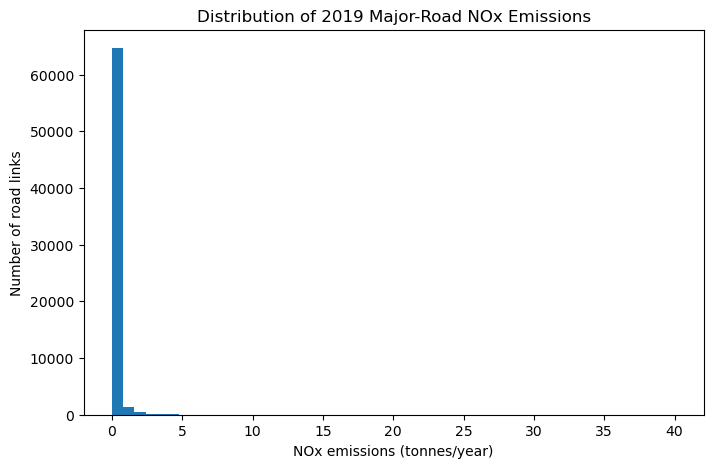

In [51]:
plt.figure(figsize=(8, 5))
plt.hist(model_base_df["NOx_total_2019"], bins=50)
plt.xlabel("NOx emissions (tonnes/year)")
plt.ylabel("Number of road links")
plt.title("Distribution of 2019 Major-Road NOx Emissions")
plt.show()

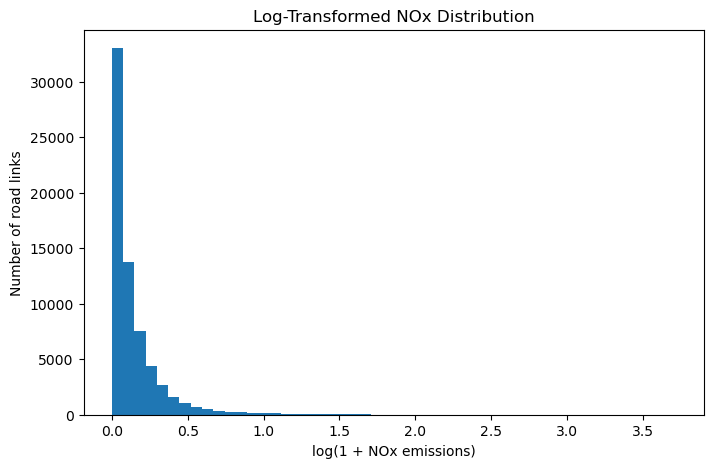

In [52]:
plt.figure(figsize=(8, 5))
plt.hist(np.log1p(model_base_df["NOx_total_2019"]), bins=50)
plt.xlabel("log(1 + NOx emissions)")
plt.ylabel("Number of road links")
plt.title("Log-Transformed NOx Distribution")
plt.show()

In [57]:
print("AADT data types:")
print(traffic_df[aadt_cols].dtypes)

print("\nSpeed data type:")
print(traffic_df["Speed (km/hr) - Except Buses"].dtype)

AADT data types:
AADT Motorcycle                                  float64
AADT Taxi                                        float64
AADT Petrol Car                                  float64
AADT Diesel Car                                  float64
AADT Electric Car                                float64
AADT Petrol PHV                                  float64
AADT Diesel PHV                                  float64
AADT Electric PHV                                float64
AADT Petrol LGV                                  float64
AADT Diesel LGV                                  float64
AADT Electric LGV                                float64
AADT 2019 - HGVs - Rigid - 2 Axles               float64
AADT 2019 - HGVs - Rigid - 3 Axles               float64
AADT 2019 - HGVs - Rigid - 4 or more Axles       float64
AADT 2019 - HGVs - Articulated - 3 to 4 Axles    float64
AADT 2019 - HGVs - Articulated - 5 Axles         float64
AADT 2019 - HGVs - Articulated - 6 Axles         float64
AADT 2019 - Bu

In [58]:
for col in aadt_cols:
    traffic_df[col] = pd.to_numeric(traffic_df[col], errors="coerce").fillna(0)

traffic_df["Speed (km/hr) - Except Buses"] = pd.to_numeric(traffic_df["Speed (km/hr) - Except Buses"], errors="coerce")
traffic_df["AADT 2019 - Total"] = pd.to_numeric(traffic_df["AADT 2019 - Total"], errors="coerce")

In [59]:
print("AADT data types after conversion:")
print(traffic_df[aadt_cols].dtypes.value_counts())

print("\nSpeed data type:")
print(traffic_df["Speed (km/hr) - Except Buses"].dtype)

AADT data types after conversion:
float64    19
Name: count, dtype: int64

Speed data type:
float64


In [60]:
traffic_london = traffic_df[traffic_df["Borough"] != "Non-GLA"].copy()

merged_df = pd.merge(traffic_london, nox_df[["TOID", "NOx_total_2019"]], on="TOID", how="inner")

model_base_df = merged_df.dropna(subset=["NOx_total_2019"]).copy()

print("Final usable road links:")
print(len(model_base_df))

Final usable road links:
66962


In [62]:
numeric_df = model_base_df.select_dtypes(include=np.number)

correlations = numeric_df.corr()["NOx_total_2019"].sort_values(ascending=False)

print(correlations.head(20))

NOx_total_2019                                   1.000000
Link Length (m)                                  0.739655
AADT 2019 - HGVs - Articulated - 6 Axles         0.616799
AADT 2019 - HGVs - Articulated - 5 Axles         0.607076
AADT 2019 - HGVs - Articulated - 3 to 4 Axles    0.532403
AADT Diesel LGV                                  0.427008
AADT 2019 - Total                                0.423249
AADT Petrol Car                                  0.401273
AADT Diesel Car                                  0.401019
AADT 2019 - HGVs - Rigid - 2 Axles               0.393016
AADT 2019 - HGVs - Rigid - 3 Axles               0.391183
AADT Petrol LGV                                  0.375731
AADT 2019 - HGVs - Rigid - 4 or more Axles       0.370182
AADT Electric Car                                0.360839
Speed (km/hr) - Except Buses                     0.303284
AADT Diesel PHV                                  0.249604
AADT Motorcycle                                  0.214890
AADT Petrol PH

In [63]:
model_base_df["VKM 2019 - Total"] = pd.to_numeric(model_base_df["VKM 2019 - Total"], errors="coerce")

print(model_base_df[["VKM 2019 - Total", "NOx_total_2019"]].corr())

                  VKM 2019 - Total  NOx_total_2019
VKM 2019 - Total          1.000000        0.985861
NOx_total_2019            0.985861        1.000000


In [64]:
feature_cols = aadt_cols + ["Speed (km/hr) - Except Buses", "Link Length (m)", "Road Classification"]

print("Number of predictors:")
print(len(feature_cols))

print("\nPredictors:")
for col in feature_cols:
    print(col)

Number of predictors:
22

Predictors:
AADT Motorcycle
AADT Taxi
AADT Petrol Car
AADT Diesel Car
AADT Electric Car
AADT Petrol PHV
AADT Diesel PHV
AADT Electric PHV
AADT Petrol LGV
AADT Diesel LGV
AADT Electric LGV
AADT 2019 - HGVs - Rigid - 2 Axles
AADT 2019 - HGVs - Rigid - 3 Axles
AADT 2019 - HGVs - Rigid - 4 or more Axles
AADT 2019 - HGVs - Articulated - 3 to 4 Axles
AADT 2019 - HGVs - Articulated - 5 Axles
AADT 2019 - HGVs - Articulated - 6 Axles
AADT 2019 - Buses
AADT 2019 - Coaches
Speed (km/hr) - Except Buses
Link Length (m)
Road Classification


In [65]:
model_df = model_base_df[["TOID", "Borough", "NOx_total_2019"] + feature_cols].copy()

print("Shape:")
print(model_df.shape)

print("\nMissing values:")
print(model_df.isna().sum().sort_values(ascending=False))

print("\nFirst 5 rows:")
print(model_df.head())

Shape:
(66962, 25)

Missing values:
TOID                                             0
Borough                                          0
NOx_total_2019                                   0
AADT Motorcycle                                  0
AADT Taxi                                        0
AADT Petrol Car                                  0
AADT Diesel Car                                  0
AADT Electric Car                                0
AADT Petrol PHV                                  0
AADT Diesel PHV                                  0
AADT Electric PHV                                0
AADT Petrol LGV                                  0
AADT Diesel LGV                                  0
AADT Electric LGV                                0
AADT 2019 - HGVs - Rigid - 2 Axles               0
AADT 2019 - HGVs - Rigid - 3 Axles               0
AADT 2019 - HGVs - Rigid - 4 or more Axles       0
AADT 2019 - HGVs - Articulated - 3 to 4 Axles    0
AADT 2019 - HGVs - Articulated - 5 Axles      

In [66]:
model_df.to_csv("laei2019_model_data.csv", index=False)

print("Shared modelling dataset saved successfully.")

Shared modelling dataset saved successfully.


The traffic and NOx datasets were joined using the unique TOID road-link identifier. After restricting the traffic data to Greater London and removing records without an available NOx target, the final modelling population contained approximately 66,962 road links. The common predictor set consisted of 19 vehicle-specific AADT variables, general traffic speed, road-link length and road classification. Vehicle-kilometre variables were excluded from the primary feature set because they are derived traffic-activity measures closely related to the construction of road-emission inventories, while vehicle-specific NOx variables were excluded to prevent target leakage.